Question: Testing resnet 50 vs resnet 101 (nb 06)


In [1]:
import os, shutil
import keras
from training import TrainingHistory, fit_model
from training import fit_model
# from training_data import TrainingData, Normalizer
import matplotlib.pyplot as plt

2023-11-09 13:36:37.817675: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-09 13:36:38.529628: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
save_path = "models/test_resnet50"
training_data_path = "training_data_synthetic"

In [3]:
from training_data import load_training_data
training_data = load_training_data(training_data_path)
levels = list(training_data.levels.keys())
depths = [1.0, 0.8, 0.6, 0.2, 0.0]
save_paths = {depth:f"{save_path}/depth_{depth:0.02f}" for depth in depths}

In [7]:
if os.path.exists(save_path):
    shutil.rmtree(save_path)
training_level = 'd0.40'
for depth in depths:
    print(f"=== training at depth {depth} ===")
    fit_model(
        training_data=training_data_path,
        training_level=training_level,
        train_depth=depth,
        optimizer=keras.optimizers.Nadam(),
        rate_scheduler={'delay': 2, 'decay': 0.8},
        save_path=save_paths[depth],
        model_type='ResNet50',
    )

=== training at depth 1.0 ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 16, 16, 2048)      23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 23593859 (90.00 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________
None
Epoch 1/10


2023-11-07 09:41:44.862457: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2023-11-07 09:41:47.134648: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-11-07 09:41:48.841586: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fb4a34eac60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-11-07 09:41:48.841607: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2023-11-07 09:41:48.897267: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-11-07 09:41:49.509084: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the p


Batch 0
saving weigts to models/test_resnet50/depth_1.00/fit_weights
 100/1554 [>.............................] - ETA: 9:25 - loss: 0.2300
Batch 100
    Training MSE (xyz, xy, z): 0.1549786733309623 0.17588464819451538 0.11316672360385609  Slopes: [-0.016448504052617073, -0.017076182180294483, -0.009324995940820166]
    Validation d0.00  MSE (xyz, xy, z): 0.0452 0.0285 0.0786  Slopes: -0.0188 -0.0195 -0.00698
    Validation d0.20  MSE (xyz, xy, z): 0.0917 0.0942 0.0869  Slopes: -0.0178 -0.0184 -0.00858
    Validation d0.40  MSE (xyz, xy, z): 0.161 0.175 0.134  Slopes: -0.0164 -0.0172 -0.00697
    Validation d0.60  MSE (xyz, xy, z): 0.266 0.302 0.194  Slopes: -0.0146 -0.0155 -0.00546
    Validation d0.80  MSE (xyz, xy, z): 0.389 0.456 0.253  Slopes: -0.0128 -0.0138 -0.00287
    Validation d1.00  MSE (xyz, xy, z): 0.541 0.659 0.304  Slopes: -0.0111 -0.012 -0.00228
 200/1554 [==>...........................] - ETA: 12:08 - loss: 0.1895
Batch 200
    Training MSE (xyz, xy, z): 0.1486287523

INFO:tensorflow:Assets written to: models/test_resnet50/depth_1.00/fit_model/assets


=== training at depth 0.8 ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 16, 16, 2048)      23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 23593859 (90.00 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________
None
Epoch 1/10

Batch 0
saving weigts to

...

 100/1554 [>.............................] - ETA: 8:55 - loss: 0.0715
Batch 100
    Training MSE (xyz, xy, z): 0.6687994701939307 0.7195342406507761 0.5673299292802398  Slopes: [-0.015448058914013164, -0.01658106134596176, 0.008555302768191888]
    Validation d0.00  MSE (xyz, xy, z): 0.533 0.535 0.529  Slopes: -0.0163 -0.0174 0.012
    Validation d0.20  MSE (xyz, xy, z): 0.583 0.593 0.561  Slopes: -0.016 -0.0172 0.00976
    Validation d0.40  MSE (xyz, xy, z): 0.634 0.644 0.612  Slopes: -0.0158 -0.017 0.00808
    Validation d0.60  MSE (xyz, xy, z): 0.77 0.814 0.683  Slopes: -0.015 -0.0163 0.00713
    Validation d0.80  MSE (xyz, xy, z): 0.879 0.935 0.769  Slopes: -0.0146 -0.0159 0.00691
    Validation d1.00  MSE (xyz, xy, z): 1.03 1.11 0.868  Slopes: -0.014 -0.0154 0.00614
 200/1554 [==>...........................] - ETA: 11:40 - loss: 0.0522
Batch 200
    Training MSE (xyz, xy, z): 0.7310173587152042 0.24496301547885302 1.703126045187907  Slopes: [-0.010163106239529063, -0.0129058610418

INFO:tensorflow:Assets written to: models/test_resnet50/depth_0.20/fit_model/assets


=== training at depth 0.0 ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 16, 16, 2048)      23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 23593859 (90.00 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________
None
Epoch 1/10

Batch 0
saving weigts to

 100/1554 [>.............................] - ETA: 9:24 - loss: 0.1282
Batch 100
    Training MSE (xyz, xy, z): 2.035679780856075 2.45103037192142 1.204978598725385  Slopes: [0.007841834065870561, 0.0066980564507972615, 0.01371847613183074]
    Validation d0.00  MSE (xyz, xy, z): 1.98 2.53 0.896  Slopes: 0.00926 0.00811 0.0181
    Validation d0.20  MSE (xyz, xy, z): 2.03 2.53 1.05  Slopes: 0.00863 0.00754 0.0154
    Validation d0.40  MSE (xyz, xy, z): 2.13 2.63 1.13  Slopes: 0.00812 0.00712 0.0139
    Validation d0.60  MSE (xyz, xy, z): 2.15 2.6 1.26  Slopes: 0.00739 0.00631 0.013
    Validation d0.80  MSE (xyz, xy, z): 2.24 2.69 1.33  Slopes: 0.00803 0.00705 0.0129
    Validation d1.00  MSE (xyz, xy, z): 2.34 2.89 1.22  Slopes: 0.00722 0.00648 0.0114
 200/1554 [==>...........................] - ETA: 12:16 - loss: 0.0946
Batch 200
    Training MSE (xyz, xy, z): 0.39401714806726323 0.2675413064510649 0.64696883129966  Slopes: [-0.0022370726513974417, -0.003630869216336739, 0.003052042172

INFO:tensorflow:Assets written to: models/test_resnet50/depth_0.00/fit_model/assets


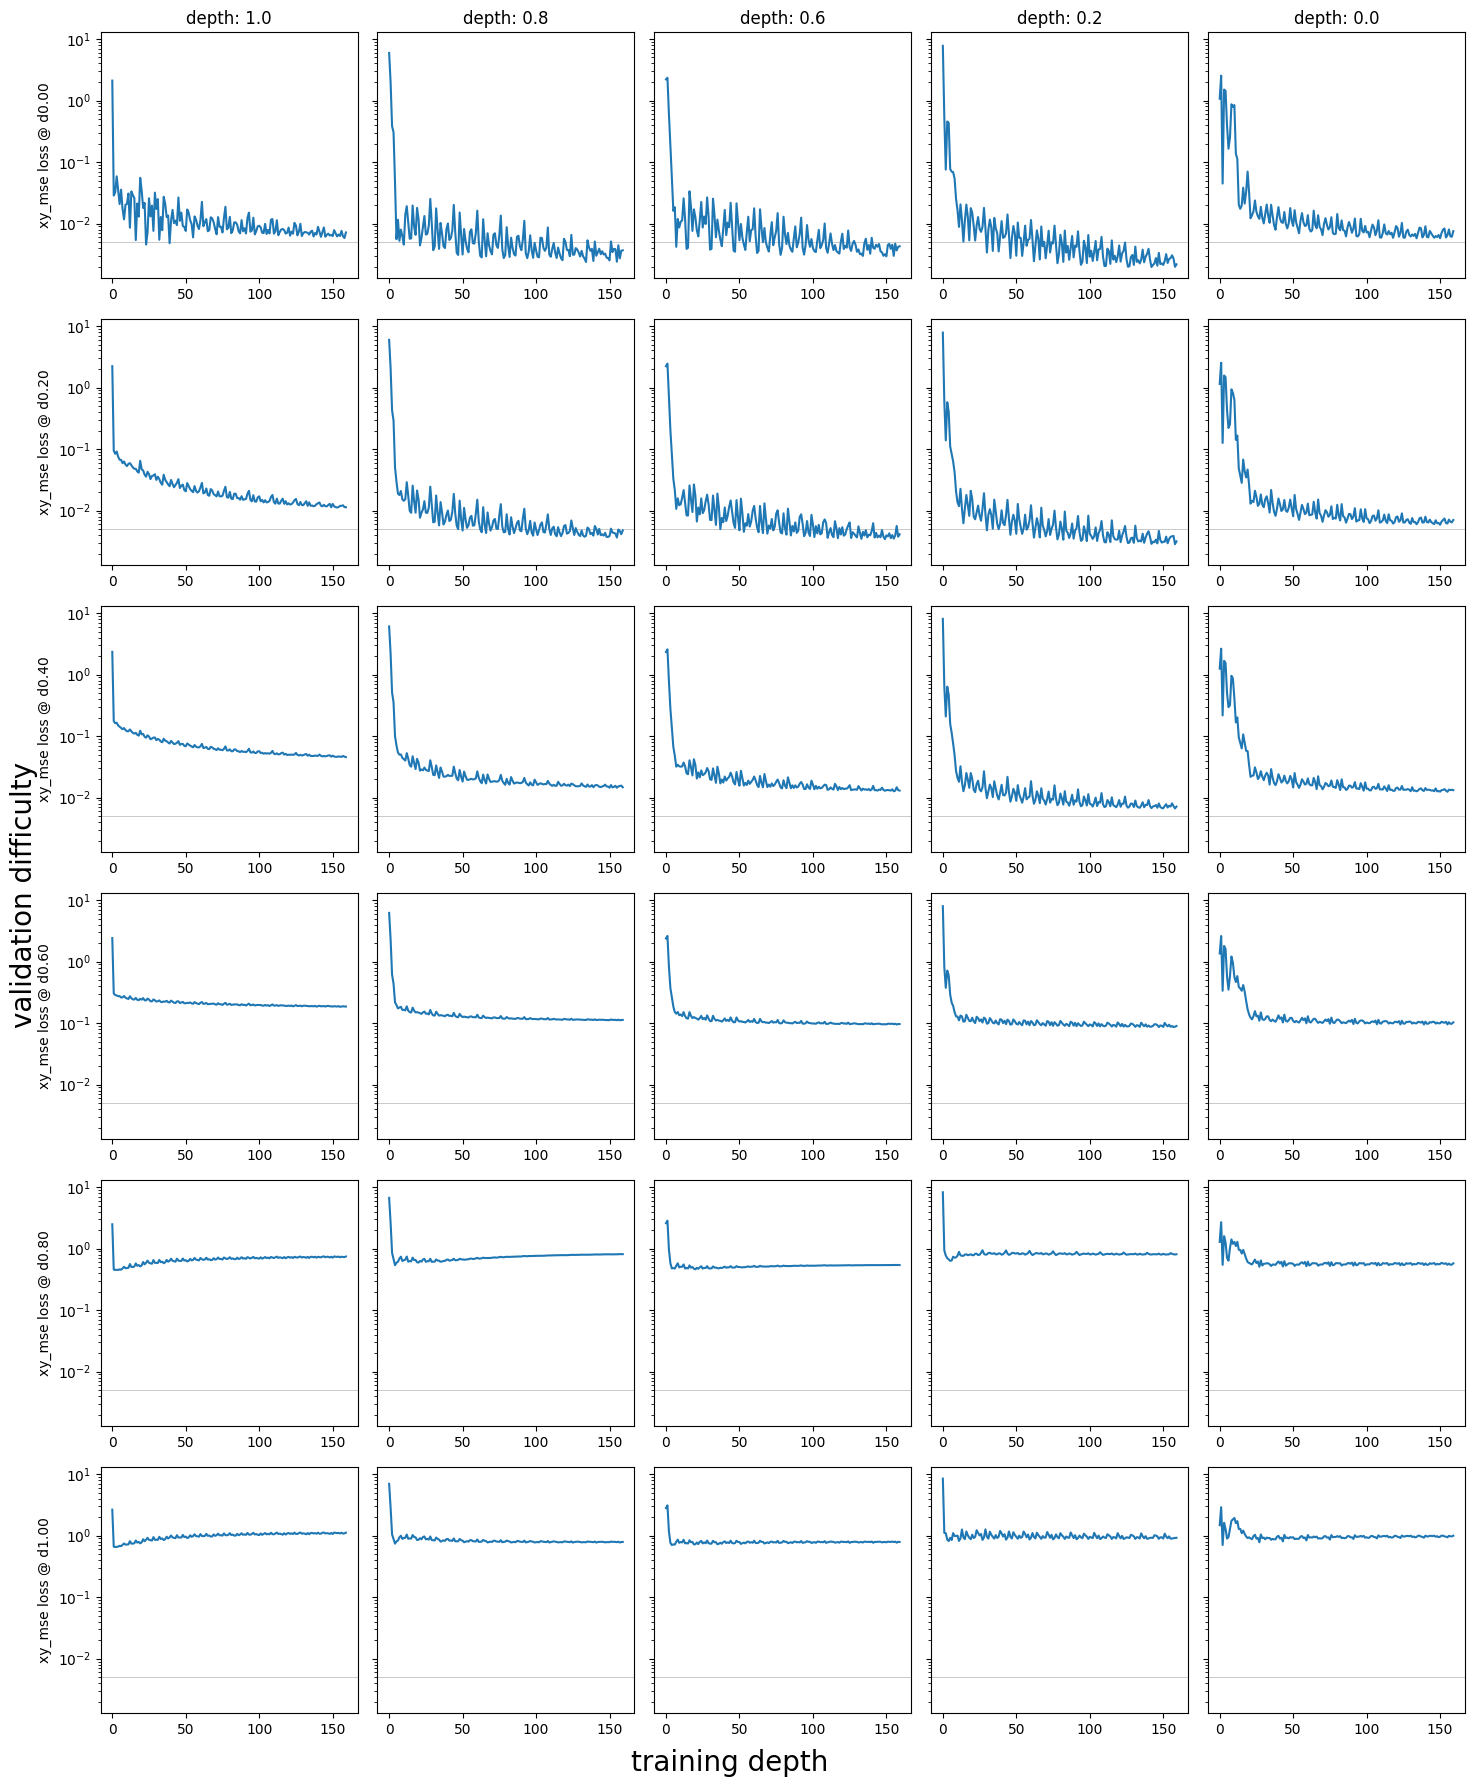

In [6]:
metric = 'xy_mse'
fig, ax = plt.subplots(len(levels), len(depths), figsize=(len(depths)*3, len(levels)*3), sharey=True)
fig.supylabel('validation difficulty', fontsize=20)
fig.supxlabel('training depth', fontsize=20)
for i, level in enumerate(levels):
    ax[i, 0].set_ylabel(f"{metric} loss @ {level}")
for i,depth in enumerate(depths):
    history = TrainingHistory(f'{save_paths[depth]}/training_history.json')
    history.plot_loss(metrics=[metric], ax=ax[:, i:i+1])
    ax[0, i].set_title(f"depth: {depth}")
fig.tight_layout()

In [9]:
from model import PipetteDetectionModel
depth = 0.8
model = PipetteDetectionModel(load_model=save_paths[depth])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 16, 16, 2048)      23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 23593859 (90.00 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________
None


1/1 [==============================] - 0s 61ms/step


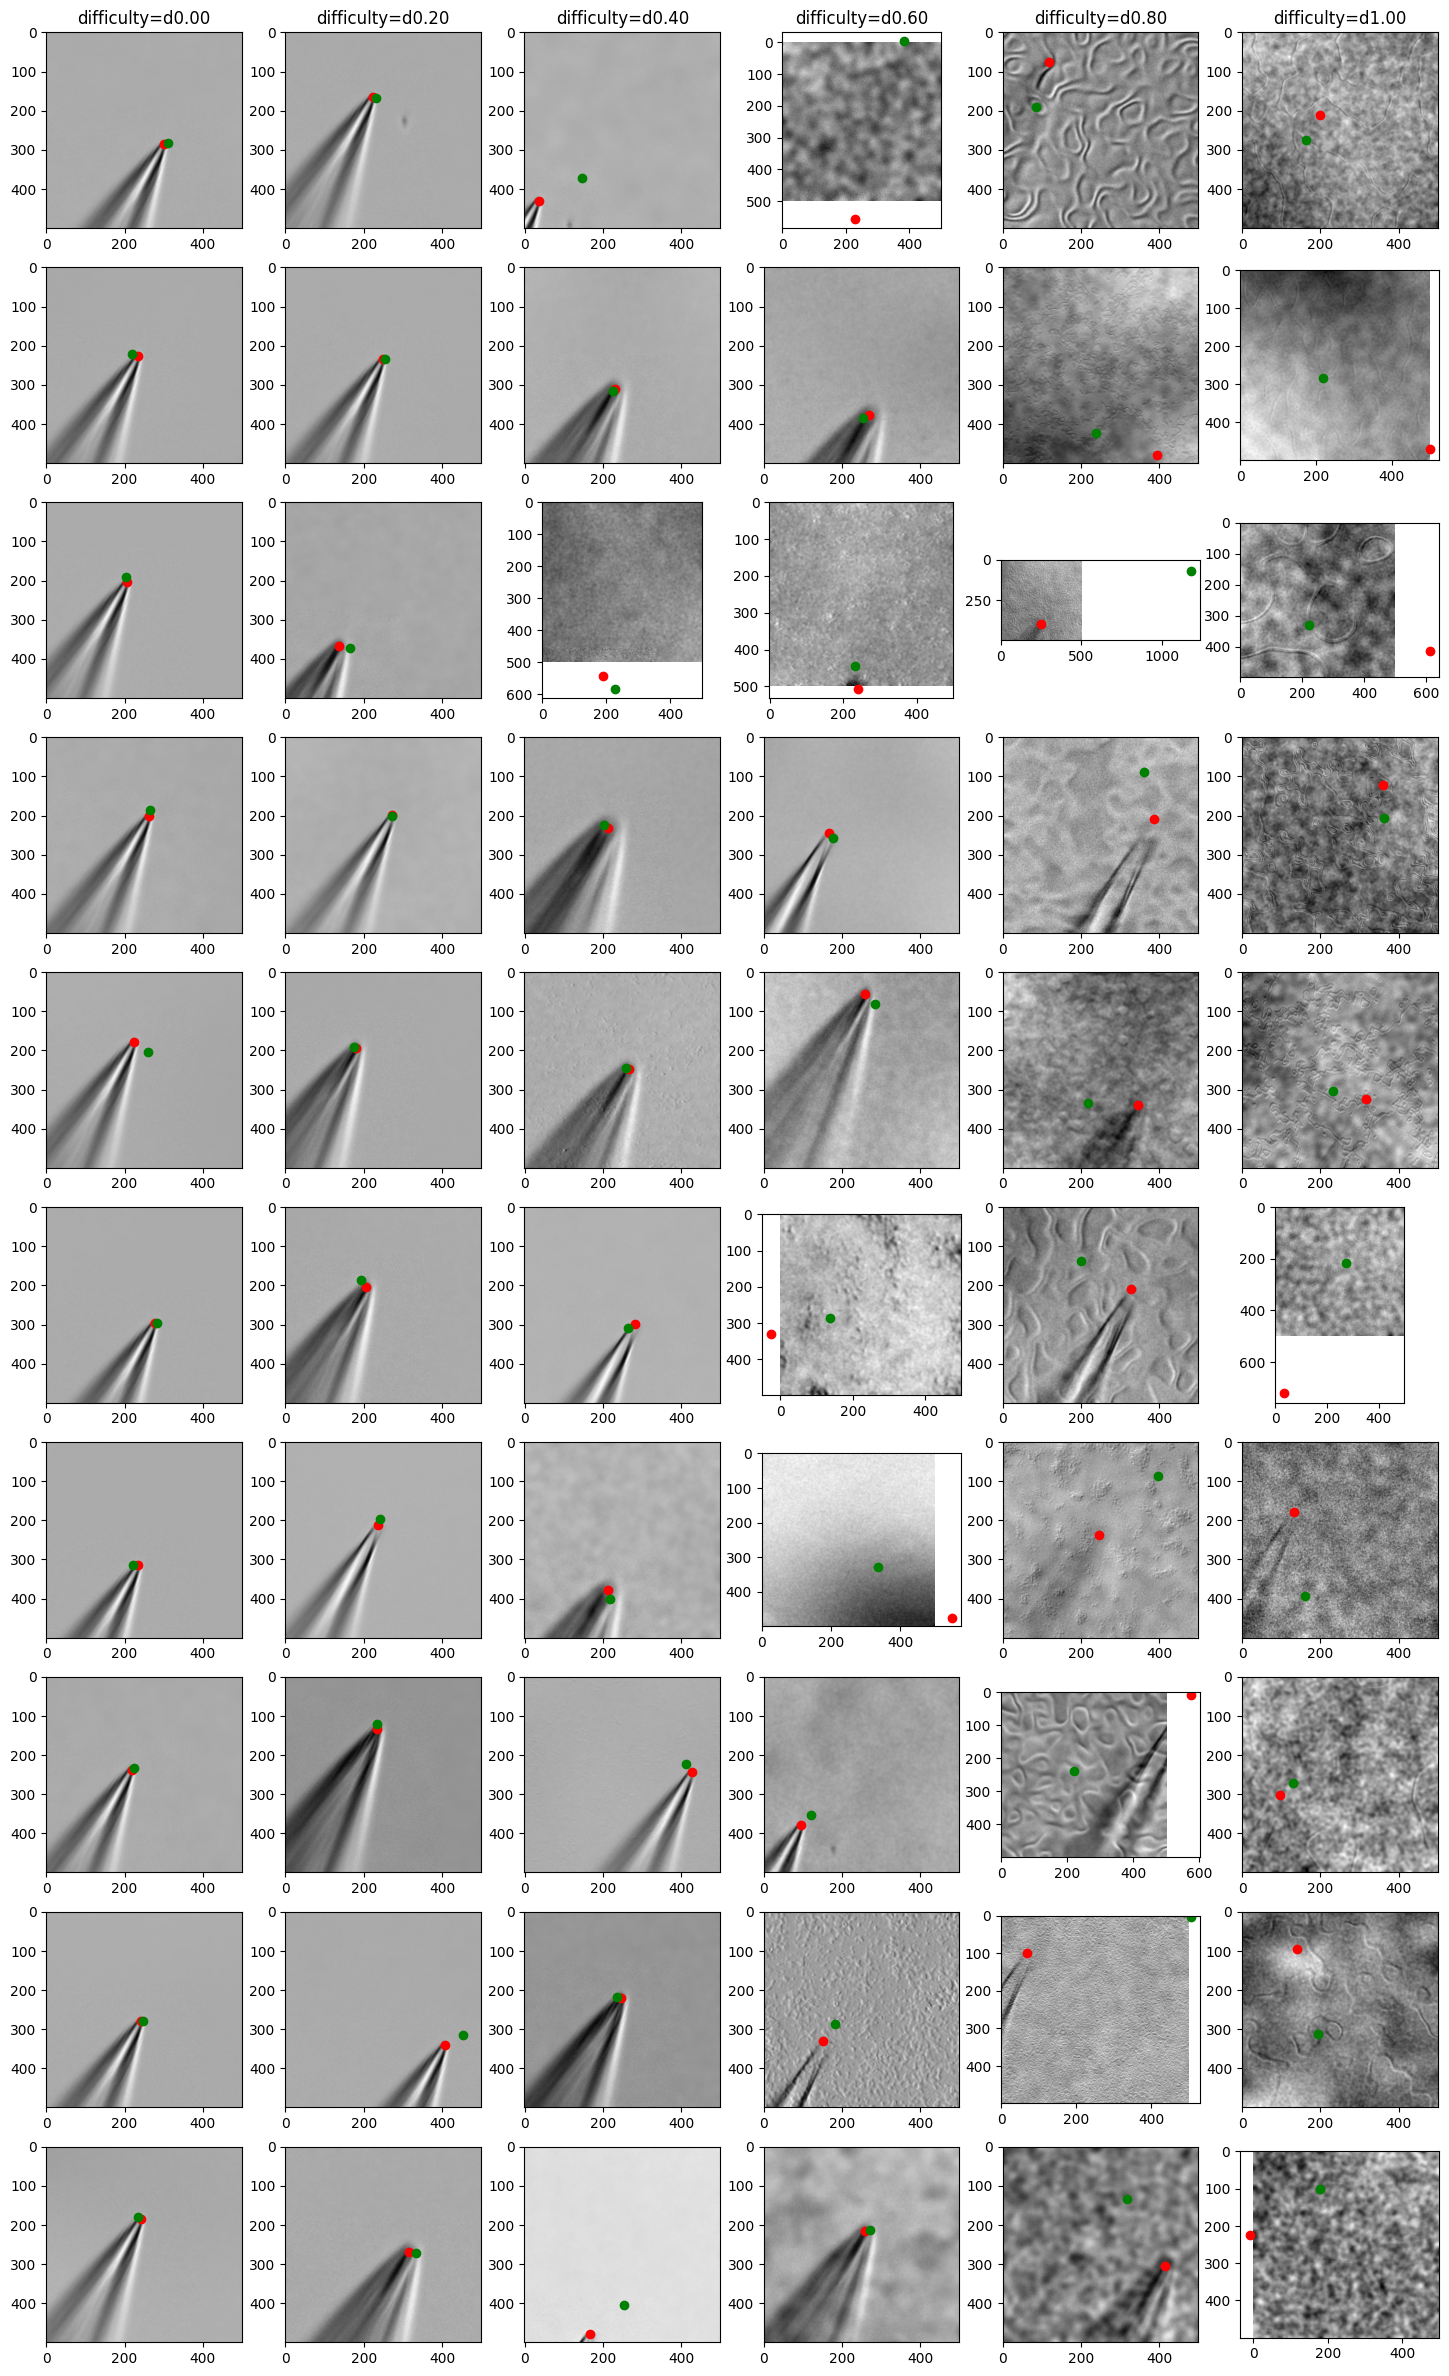

In [10]:
shape = (10, len(levels))
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j, level in enumerate(levels):
    ax[0,j].set_title(f"difficulty={level}")
    image, pip_pos = training_data.levels[level][:shape[0]].get_arrays()
    pip_pos = training_data.output_norm.denormalize(pip_pos)
    pred = training_data.output_norm.denormalize(model.model.predict(image))
    for i in range(shape[0]):
        ax[i,j].imshow(image[i], cmap='gray')
        ax[i,j].scatter(pip_pos[i, 2], pip_pos[i, 1], color='red')
        ax[i,j].scatter(pred[i, 2], pred[i, 1], color='green')
        